# MRI Quality Control — Model Training & Evaluation
## Team NIRMATA | Hackathon

### Overview
This notebook trains and evaluates the ML classification model for MRI quality control.

**Pipeline:**
1. Load MRIQC IQM dataset (1500 labeled samples)
2. Exploratory Data Analysis
3. Handle class imbalance (SMOTE + class weights)
4. Train Ensemble: XGBoost + Random Forest + MLP
5. Stratified 5-Fold Cross-Validation
6. Confusion Matrix + Classification Report
7. SHAP Explainability Analysis
8. Export final model for inference pipeline

**Dataset:** 1500 MRI scans with 22 MRIQC Image Quality Metrics (IQMs)  
**Classes:** Pass (1122) | Review (256) | Fail (122)  
**Models:** XGBoost, Random Forest, MLP, Soft Voting Ensemble

In [1]:
# Installation (run once)
!pip install xgboost shap imbalanced-learn --quiet

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded.")

All libraries loaded.


## 1. Load Dataset

In [3]:
# ========== CHANGE THIS PATH ==========
DATASET_PATH = "/kaggle/input/datasets/selvadineshs/1600-dataset/mriqc_combined_dataset.json"
# =======================================

with open(DATASET_PATH, 'r') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
print(f"Dataset: {len(df)} samples, {len(df.columns)} columns")
print(f"\nClass distribution:")
print(df['quality_label'].value_counts())
print(f"\nClass percentages:")
print(df['quality_label'].value_counts(normalize=True).mul(100).round(1))

Dataset: 1600 samples, 24 columns

Class distribution:
quality_label
pass      1222
review     256
fail       122
Name: count, dtype: int64

Class percentages:
quality_label
pass      76.4
review    16.0
fail       7.6
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis

In [4]:
FEATURE_COLUMNS = [
    'cjv', 'cnr', 'efc', 'fber', 'fwhm_avg', 'inu_med', 'inu_range',
    'qi_1', 'qi_2', 'snr_csf', 'snr_gm', 'snr_total', 'snr_wm', 'snrd_total',
    'icvs_csf', 'icvs_gm', 'icvs_wm', 'wm2max',
    'summary_bg_mean', 'summary_bg_stdv', 'summary_gm_mean', 'summary_wm_mean'
]

print(f"Features: {len(FEATURE_COLUMNS)}")
print(f"\nFeature statistics:")
df[FEATURE_COLUMNS].describe().round(3)

Features: 22

Feature statistics:


,cjv,cnr,efc,fber,fwhm_avg,inu_med,inu_range,qi_1,qi_2,snr_csf,...,snr_wm,snrd_total,icvs_csf,icvs_gm,icvs_wm,wm2max,summary_bg_mean,summary_bg_stdv,summary_gm_mean,summary_wm_mean
count,1600.000,1600.000,1600.000,1600.000,1600.000,1600.000,1600.000,1600.000,1600.000,1600.000,...,1600.000,1600.000,1600.000,1600.000,1600.000,1600.000,1600.000,1600.000,1600.000,1600.000
mean,0.687,2.495,0.601,2714.992,3.157,1.148,0.378,0.020,0.070,4.916,...,14.351,59.806,0.238,0.406,0.356,0.480,40.312,30.566,1079.418,1042.905
std,2.784,1.037,0.122,20169.777,0.988,0.204,0.140,0.053,0.170,4.541,...,6.857,61.777,0.077,0.104,0.110,0.203,51.873,39.929,598.080,244.319
min,0.132,0.009,0.405,12.736,0.000,0.530,0.074,0.000,0.000,0.366,...,0.593,2.881,0.099,0.024,0.008,0.067,0.000,4.006,304.081,385.046
25%,0.386,1.636,0.533,220.060,2.885,1.024,0.290,0.000,0.002,2.480,...,9.210,30.273,0.186,0.393,0.345,0.290,11.038,9.677,697.133,998.464
50%,0.501,2.577,0.574,1469.269,3.355,1.149,0.359,0.000,0.006,3.217,...,15.560,48.906,0.216,0.418,0.375,0.514,18.514,15.100,794.533,1000.811
75%,0.687,3.233,0.625,2812.232,3.658,1.246,0.443,0.001,0.042,5.227,...,19.289,67.983,0.263,0.444,0.397,0.610,41.088,29.300,1481.424,1004.505
max,78.417,6.825,0.999,800484.188,5.369,2.498,1.072,0.275,1.000,42.567,...,37.855,882.920,0.594,0.715,0.705,1.066,501.941,606.301,7030.927,8454.928


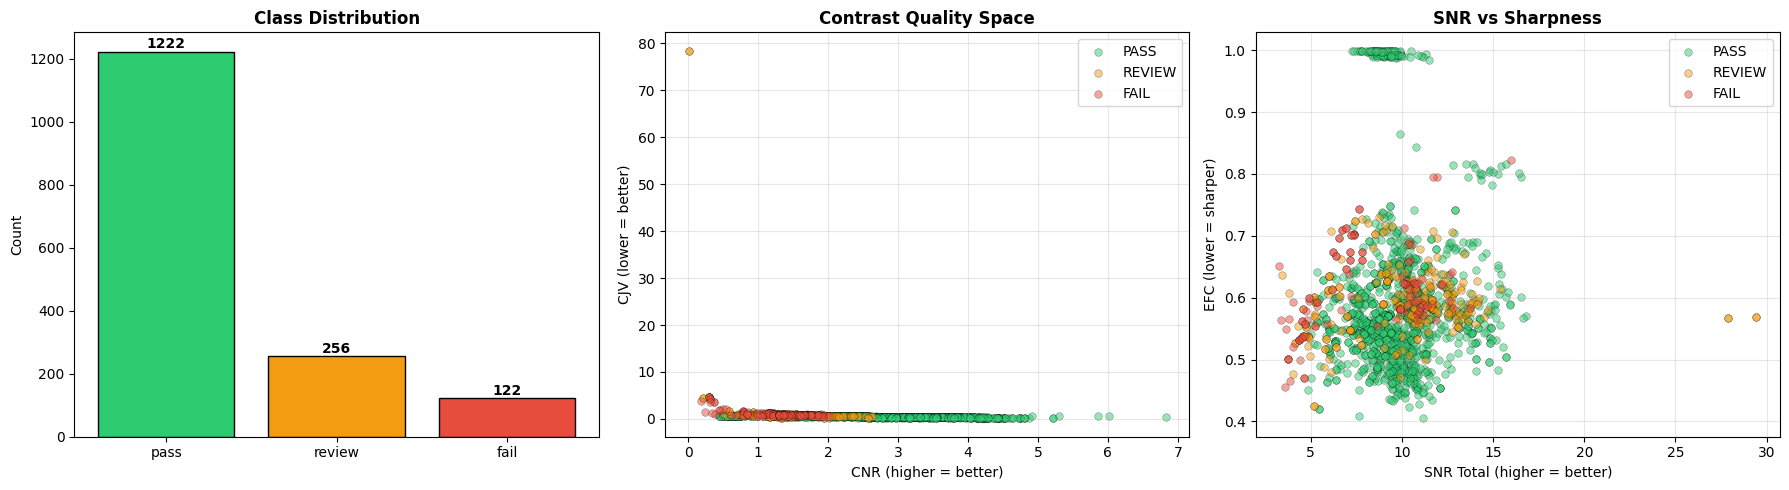

In [5]:
# Class distribution plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart of class counts
colors = {'pass': '#2ecc71', 'review': '#f39c12', 'fail': '#e74c3c'}
counts = df['quality_label'].value_counts()
axes[0].bar(counts.index, counts.values, color=[colors[c] for c in counts.index], edgecolor='black')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (label, count) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, count + 10, str(count), ha='center', fontweight='bold')

# CNR vs CJV colored by class
for label, color in colors.items():
    mask = df['quality_label'] == label
    axes[1].scatter(df[mask]['cnr'], df[mask]['cjv'], c=color, label=label.upper(),
                    alpha=0.5, s=30, edgecolors='black', linewidth=0.3)
axes[1].set_xlabel('CNR (higher = better)')
axes[1].set_ylabel('CJV (lower = better)')
axes[1].set_title('Contrast Quality Space', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# SNR Total vs EFC
for label, color in colors.items():
    mask = df['quality_label'] == label
    axes[2].scatter(df[mask]['snr_total'], df[mask]['efc'], c=color, label=label.upper(),
                    alpha=0.5, s=30, edgecolors='black', linewidth=0.3)
axes[2].set_xlabel('SNR Total (higher = better)')
axes[2].set_ylabel('EFC (lower = sharper)')
axes[2].set_title('SNR vs Sharpness', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

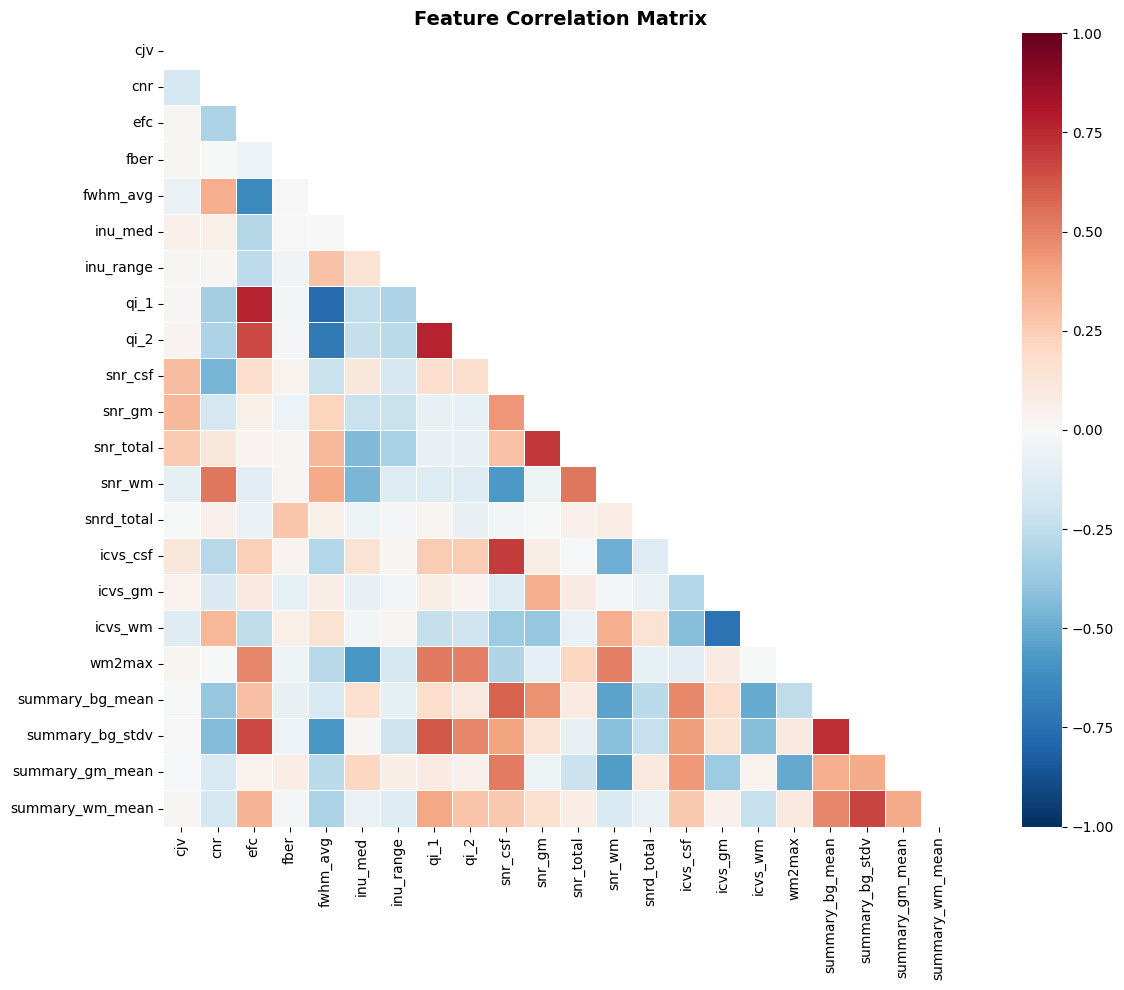

In [6]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[FEATURE_COLUMNS].corr()
mask_tri = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_tri, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Data Preparation

In [7]:
# Prepare features and labels
X = df[FEATURE_COLUMNS].values
le = LabelEncoder()
y = le.fit_transform(df['quality_label'])  # fail=0, pass=1, review=2

print(f"Feature matrix: {X.shape}")
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"\nChecking for NaN/Inf:")
print(f"  NaN count: {np.isnan(X).sum()}")
print(f"  Inf count: {np.isinf(X).sum()}")

# Replace any NaN/Inf with column median
for col in range(X.shape[1]):
    col_data = X[:, col]
    mask = np.isfinite(col_data)
    if not mask.all():
        median_val = np.median(col_data[mask])
        col_data[~mask] = median_val
        print(f"  Fixed column '{FEATURE_COLUMNS[col]}': {(~mask).sum()} values replaced")

print("\nData ready.")

Feature matrix: (1600, 22)
Label encoding: {'fail': np.int64(0), 'pass': np.int64(1), 'review': np.int64(2)}

Checking for NaN/Inf:
  NaN count: 0
  Inf count: 0

Data ready.


## 4. Model Definitions

We use three diverse classifiers + a soft voting ensemble:
- **XGBoost**: Gradient boosted trees — strong on tabular data
- **Random Forest**: Bagged decision trees — robust, low variance
- **MLP**: Multi-layer perceptron — captures non-linear relationships
- **Ensemble**: Soft voting across all three — best generalization

In [8]:
# Compute class weights for imbalanced data
from sklearn.utils.class_weight import compute_sample_weight

class_counts = np.bincount(y)
n_samples = len(y)
n_classes = len(class_counts)
class_weights = {i: n_samples / (n_classes * count) for i, count in enumerate(class_counts)}
print(f"Class weights: {class_weights}")

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_weight=3,
    scale_pos_weight=1,
    random_state=42,
    eval_metric='mlogloss'
)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# MLP
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=32,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42
)

# Ensemble
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model),
        ('mlp', mlp_model)
    ],
    voting='soft',
    weights=[2, 1, 1]  # XGBoost gets higher weight
)

print("Models defined:")
print("  1. XGBoost (300 trees, depth=6, lr=0.05)")
print("  2. Random Forest (300 trees, depth=12, balanced weights)")
print("  3. MLP (128-64-32, ReLU, early stopping)")
print("  4. Soft Voting Ensemble (XGB:2, RF:1, MLP:1)")

Class weights: {0: np.float64(4.371584699453552), 1: np.float64(0.436442989634479), 2: np.float64(2.0833333333333335)}
Models defined:
  1. XGBoost (300 trees, depth=6, lr=0.05)
  2. Random Forest (300 trees, depth=12, balanced weights)
  3. MLP (128-64-32, ReLU, early stopping)
  4. Soft Voting Ensemble (XGB:2, RF:1, MLP:1)


## 5. Stratified 5-Fold Cross-Validation

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

models = {
    'XGBoost': xgb_model,
    'Random Forest': rf_model,
    'MLP': mlp_model,
    'Ensemble': ensemble_model
}

cv_results = {}

print("Running 5-Fold Stratified Cross-Validation with SMOTE...")
print("=" * 70)

for name, model in models.items():
    print(f"\n{'─'*70}")
    print(f"  Model: {name}")
    print(f"{'─'*70}")
    
    fold_accuracies = []
    fold_f1s = []
    all_preds = np.zeros(len(y), dtype=int)
    all_probas = np.zeros((len(y), n_classes))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Apply SMOTE to training data only
        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        
        # Scale features (fit on train, transform both)
        X_train_scaled = scaler.fit_transform(X_train_res)
        X_val_scaled = scaler.transform(X_val)
        
        # For XGBoost and RF, use unscaled; for MLP and Ensemble, use scaled
        if name in ['MLP', 'Ensemble']:
            model.fit(X_train_scaled, y_train_res)
            preds = model.predict(X_val_scaled)
            probas = model.predict_proba(X_val_scaled)
        else:
            # XGBoost with sample weights for imbalance
            if name == 'XGBoost':
                sw = compute_sample_weight('balanced', y_train_res)
                model.fit(X_train_res, y_train_res, sample_weight=sw)
            else:
                model.fit(X_train_res, y_train_res)
            preds = model.predict(X_val)
            probas = model.predict_proba(X_val)
        
        all_preds[val_idx] = preds
        all_probas[val_idx] = probas
        
        fold_acc = accuracy_score(y_val, preds)
        fold_f1 = f1_score(y_val, preds, average='macro')
        fold_accuracies.append(fold_acc)
        fold_f1s.append(fold_f1)
        
        print(f"  Fold {fold+1}: Accuracy={fold_acc:.4f} | Macro-F1={fold_f1:.4f}")
    
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    mean_f1 = np.mean(fold_f1s)
    std_f1 = np.std(fold_f1s)
    
    cv_results[name] = {
        'accuracy': mean_acc,
        'accuracy_std': std_acc,
        'f1_macro': mean_f1,
        'f1_std': std_f1,
        'predictions': all_preds,
        'probabilities': all_probas
    }
    
    print(f"  ────────────────────────────────")
    print(f"  Mean Accuracy: {mean_acc:.4f} +/- {std_acc:.4f}")
    print(f"  Mean Macro-F1: {mean_f1:.4f} +/- {std_f1:.4f}")

Running 5-Fold Stratified Cross-Validation with SMOTE...

──────────────────────────────────────────────────────────────────────
  Model: XGBoost
──────────────────────────────────────────────────────────────────────
  Fold 1: Accuracy=0.9625 | Macro-F1=0.9253
  Fold 2: Accuracy=0.9656 | Macro-F1=0.9188
  Fold 3: Accuracy=0.9563 | Macro-F1=0.9224
  Fold 4: Accuracy=0.9531 | Macro-F1=0.8968
  Fold 5: Accuracy=0.9688 | Macro-F1=0.9416
  ────────────────────────────────
  Mean Accuracy: 0.9613 +/- 0.0058
  Mean Macro-F1: 0.9210 +/- 0.0144

──────────────────────────────────────────────────────────────────────
  Model: Random Forest
──────────────────────────────────────────────────────────────────────
  Fold 1: Accuracy=0.9594 | Macro-F1=0.9400
  Fold 2: Accuracy=0.9594 | Macro-F1=0.9174
  Fold 3: Accuracy=0.9469 | Macro-F1=0.9104
  Fold 4: Accuracy=0.9375 | Macro-F1=0.8662
  Fold 5: Accuracy=0.9531 | Macro-F1=0.9199
  ────────────────────────────────
  Mean Accuracy: 0.9512 +/- 0.0083
  

## 6. Model Comparison Summary


                           MODEL COMPARISON                           
Model                    Accuracy     Macro-F1   Std(Acc)    Std(F1)
----------------------------------------------------------------------
XGBoost                   0.9613       0.9210     0.0058     0.0144
Random Forest             0.9512       0.9108     0.0083     0.0243
MLP                       0.9475       0.8975     0.0067     0.0286
Ensemble                  0.9600       0.9209     0.0103     0.0245
----------------------------------------------------------------------
Best model: XGBoost (Macro-F1 = 0.9210)


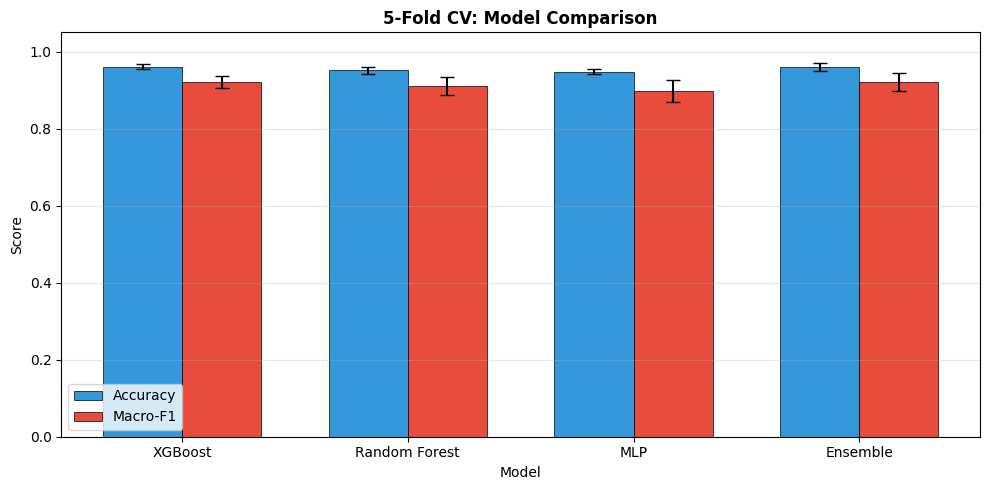

In [10]:
# Summary table
print("\n" + "=" * 70)
print(f"{'MODEL COMPARISON':^70}")
print("=" * 70)
print(f"{'Model':<20} {'Accuracy':>12} {'Macro-F1':>12} {'Std(Acc)':>10} {'Std(F1)':>10}")
print("-" * 70)

best_model_name = None
best_f1 = 0

for name, res in cv_results.items():
    print(f"{name:<20} {res['accuracy']:>11.4f} {res['f1_macro']:>12.4f} {res['accuracy_std']:>10.4f} {res['f1_std']:>10.4f}")
    if res['f1_macro'] > best_f1:
        best_f1 = res['f1_macro']
        best_model_name = name

print("-" * 70)
print(f"Best model: {best_model_name} (Macro-F1 = {best_f1:.4f})")
print("=" * 70)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
model_names = list(cv_results.keys())
accs = [cv_results[m]['accuracy'] for m in model_names]
f1s = [cv_results[m]['f1_macro'] for m in model_names]
acc_stds = [cv_results[m]['accuracy_std'] for m in model_names]
f1_stds = [cv_results[m]['f1_std'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35
ax.bar(x - width/2, accs, width, yerr=acc_stds, label='Accuracy', color='#3498db', capsize=5, edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, f1s, width, yerr=f1_stds, label='Macro-F1', color='#e74c3c', capsize=5, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('5-Fold CV: Model Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. Confusion Matrix & Classification Report
Using the cross-validated predictions (each sample predicted when it was in the validation fold — no data leakage).

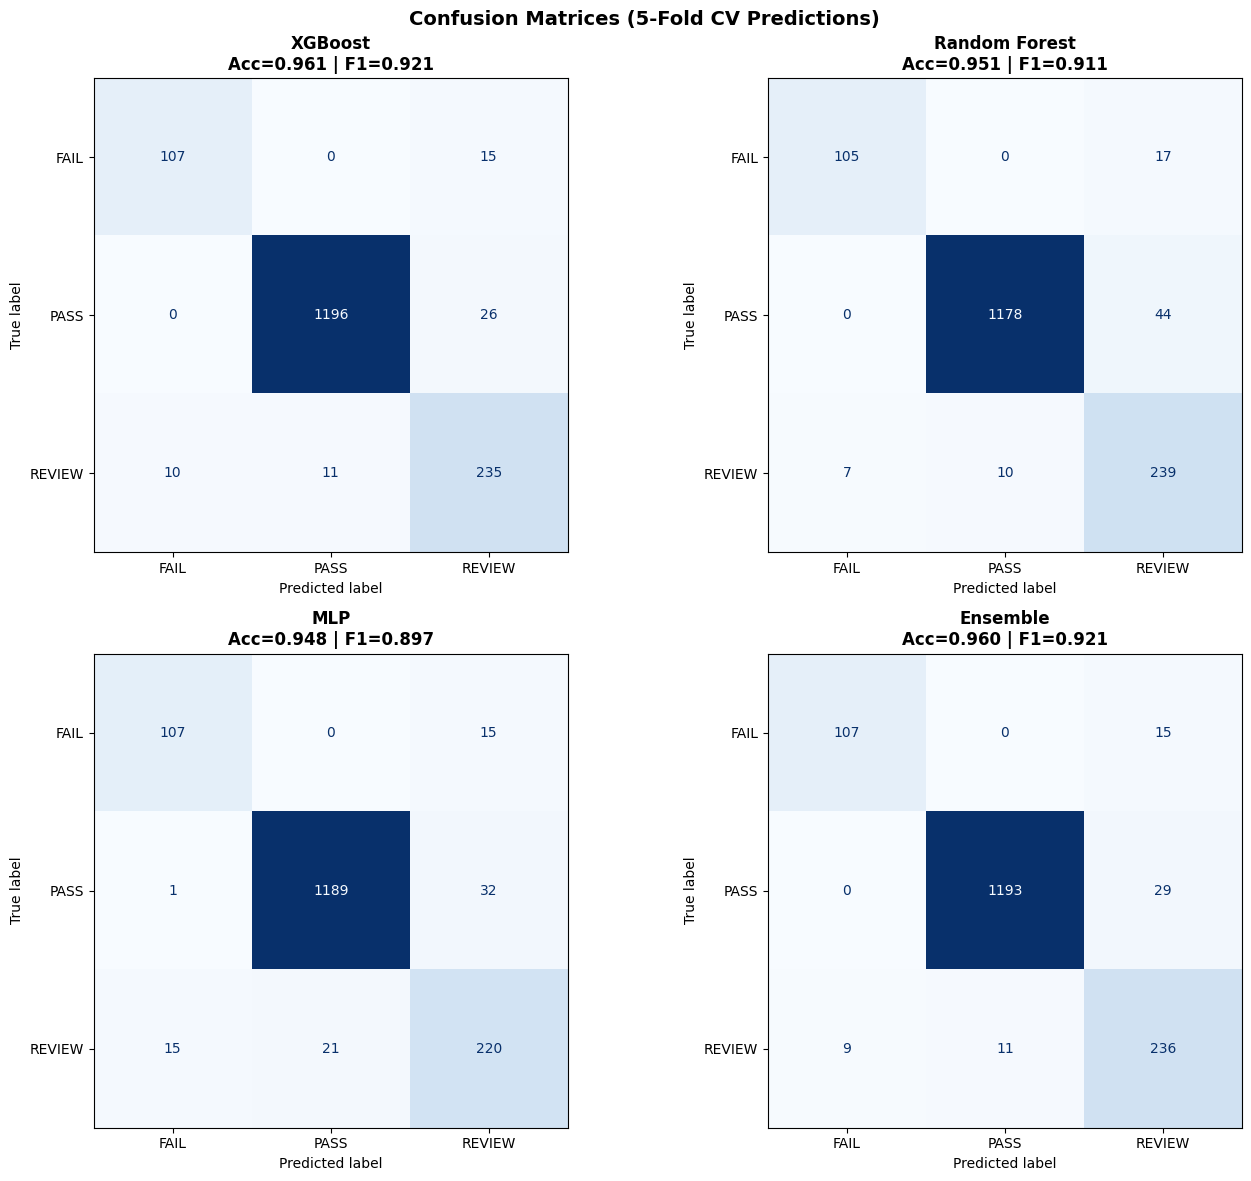

In [11]:
# Show confusion matrix for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices (5-Fold CV Predictions)', fontsize=14, fontweight='bold')

class_names = le.classes_  # ['fail', 'pass', 'review']

for idx, (name, res) in enumerate(cv_results.items()):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y, res['predictions'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[c.upper() for c in class_names])
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f'{name}\nAcc={res["accuracy"]:.3f} | F1={res["f1_macro"]:.3f}', fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
# Detailed classification report for best model
print(f"\n{'='*70}")
print(f"DETAILED CLASSIFICATION REPORT — {best_model_name}")
print(f"{'='*70}\n")
print(classification_report(
    y, cv_results[best_model_name]['predictions'],
    target_names=[c.upper() for c in class_names],
    digits=4
))

# Also show for XGBoost specifically (since that's what we export)
if best_model_name != 'XGBoost':
    print(f"\n{'='*70}")
    print(f"CLASSIFICATION REPORT — XGBoost (exported model)")
    print(f"{'='*70}\n")
    print(classification_report(
        y, cv_results['XGBoost']['predictions'],
        target_names=[c.upper() for c in class_names],
        digits=4
    ))


DETAILED CLASSIFICATION REPORT — XGBoost

              precision    recall  f1-score   support

        FAIL     0.9145    0.8770    0.8954       122
        PASS     0.9909    0.9787    0.9848      1222
      REVIEW     0.8514    0.9180    0.8835       256

    accuracy                         0.9613      1600
   macro avg     0.9190    0.9246    0.9212      1600
weighted avg     0.9628    0.9613    0.9617      1600



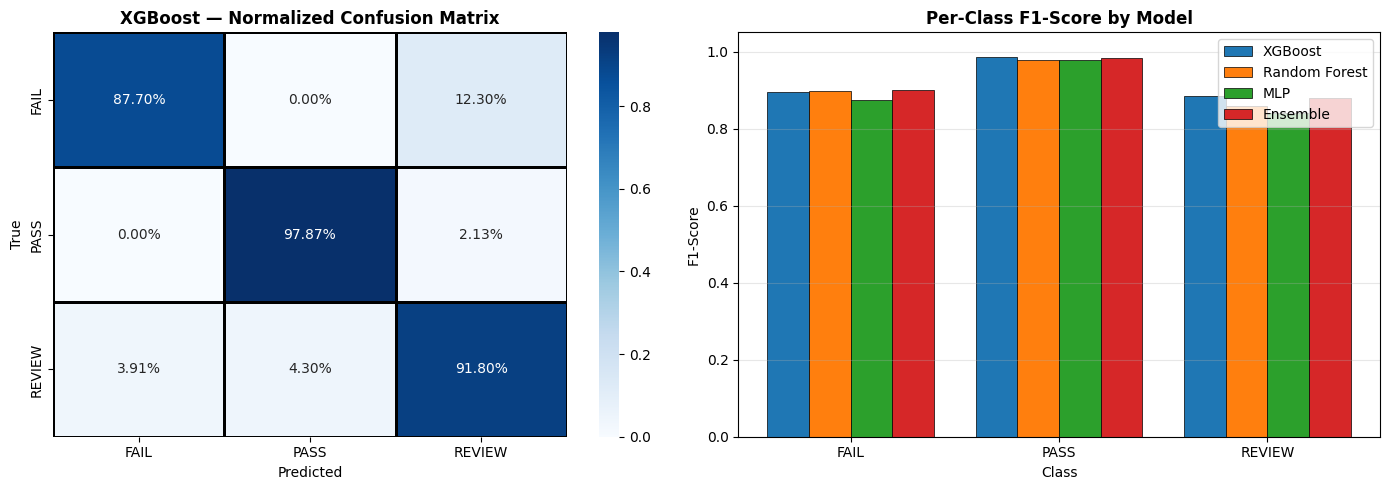

In [13]:
# Per-class metrics visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normalized confusion matrix for best model
cm = confusion_matrix(y, cv_results[best_model_name]['predictions'])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

ax = axes[0]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=[c.upper() for c in class_names],
            yticklabels=[c.upper() for c in class_names], ax=ax,
            linewidths=1, linecolor='black')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'{best_model_name} — Normalized Confusion Matrix', fontweight='bold')

# Per-class F1 comparison across models
ax = axes[1]
per_class_f1 = {}
for name, res in cv_results.items():
    report = classification_report(y, res['predictions'], target_names=class_names, output_dict=True)
    per_class_f1[name] = [report[c]['f1-score'] for c in class_names]

x = np.arange(len(class_names))
width = 0.2
for i, (name, f1s) in enumerate(per_class_f1.items()):
    ax.bar(x + i * width, f1s, width, label=name, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Class')
ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1-Score by Model', fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([c.upper() for c in class_names])
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. SHAP Explainability Analysis
Understanding which features drive the model's decisions — critical for medical ML.

In [14]:
# Train final XGBoost on full dataset with SMOTE for SHAP analysis
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
sw = compute_sample_weight('balanced', y_res)

xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_weight=3,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_final.fit(X_res, y_res, sample_weight=sw)

print("Final XGBoost trained on full SMOTE-resampled dataset.")
print(f"Training samples after SMOTE: {len(X_res)} (original: {len(X)})")

Final XGBoost trained on full SMOTE-resampled dataset.
Training samples after SMOTE: 3666 (original: 1600)


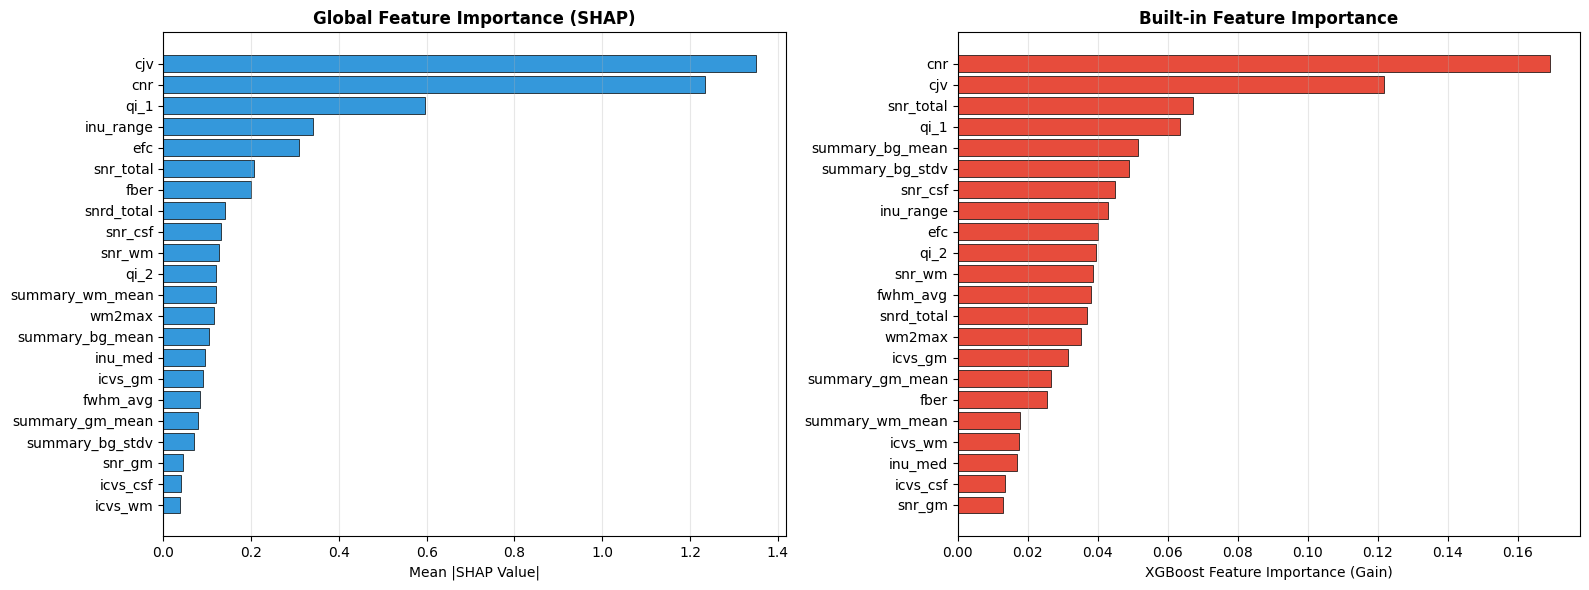

In [15]:
# SHAP values
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X)

# Handle different SHAP output formats:
# Newer SHAP: 3D array (samples, features, classes)
# Older SHAP: list of 2D arrays [class0_array, class1_array, ...]
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    mean_shap = np.abs(shap_values).mean(axis=(0, 2))
    shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
elif isinstance(shap_values, list):
    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    shap_values_list = shap_values
else:
    mean_shap = np.abs(shap_values).mean(axis=0)
    shap_values_list = None

# Global feature importance (mean |SHAP|)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot - mean SHAP importance
ax = axes[0]
sorted_idx = np.argsort(mean_shap)
ax.barh(range(len(FEATURE_COLUMNS)), mean_shap[sorted_idx], color='#3498db', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(FEATURE_COLUMNS)))
ax.set_yticklabels([FEATURE_COLUMNS[i] for i in sorted_idx])
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Global Feature Importance (SHAP)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# XGBoost built-in importance for comparison
ax = axes[1]
importances = xgb_final.feature_importances_
sorted_idx2 = np.argsort(importances)
ax.barh(range(len(FEATURE_COLUMNS)), importances[sorted_idx2], color='#e74c3c', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(FEATURE_COLUMNS)))
ax.set_yticklabels([FEATURE_COLUMNS[i] for i in sorted_idx2])
ax.set_xlabel('XGBoost Feature Importance (Gain)')
ax.set_title('Built-in Feature Importance', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

SHAP Summary — how each feature pushes predictions:

--- Class: FAIL ---


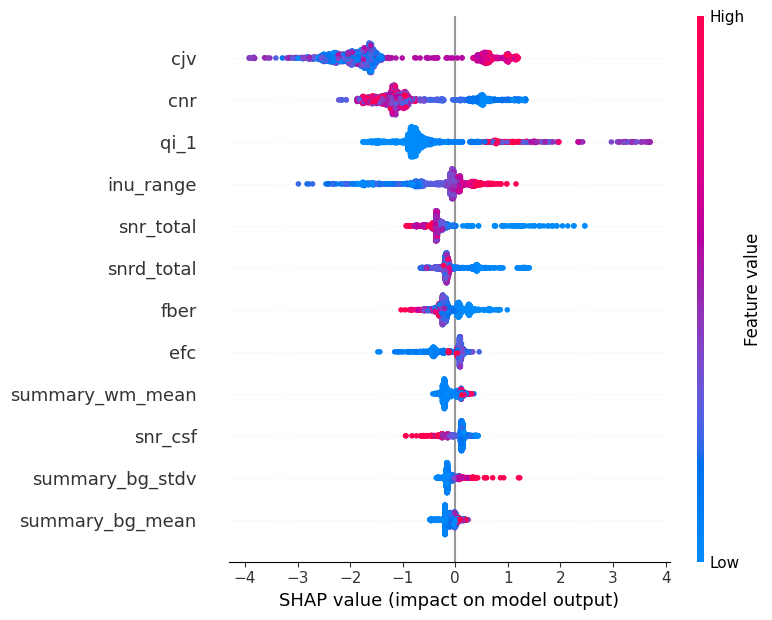


--- Class: PASS ---


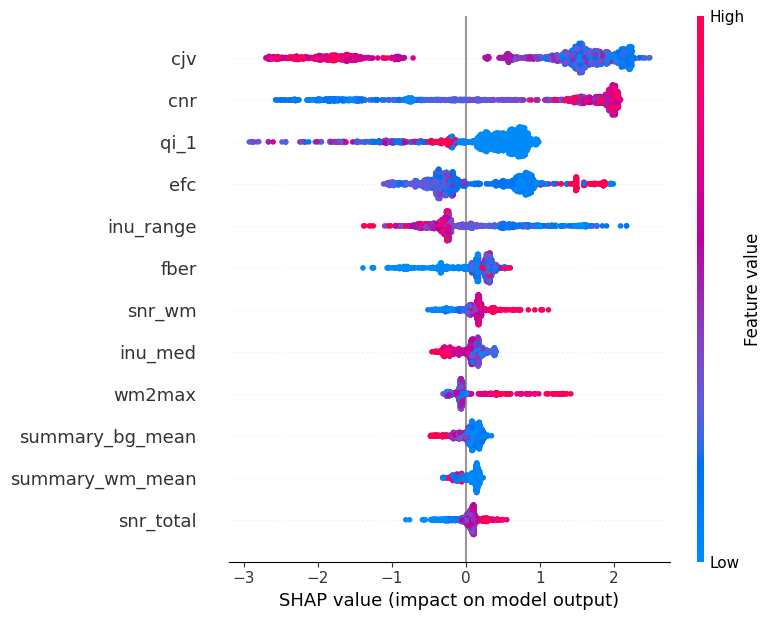


--- Class: REVIEW ---


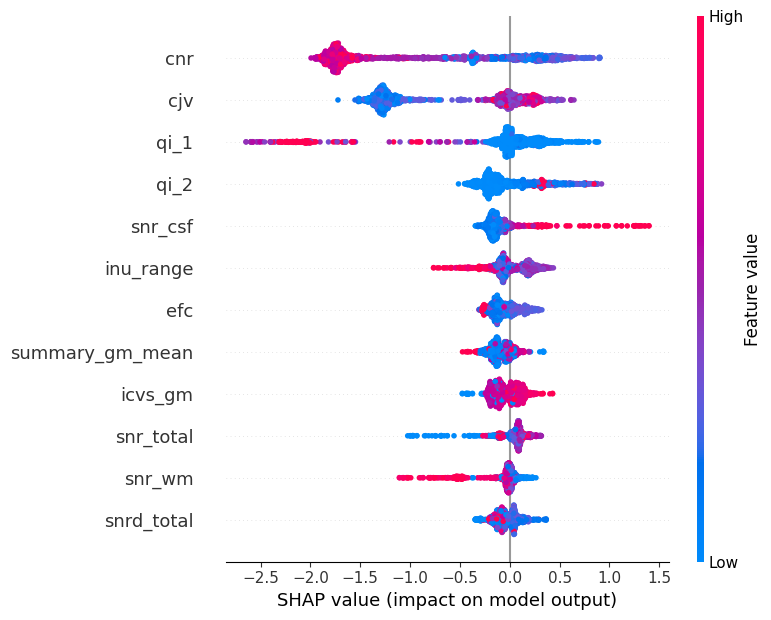

In [16]:
# SHAP summary plot (beeswarm)
print("SHAP Summary — how each feature pushes predictions:")
if shap_values_list is not None:
    for i, class_name in enumerate(class_names):
        print(f"\n--- Class: {class_name.upper()} ---")
        shap.summary_plot(shap_values_list[i], X, feature_names=FEATURE_COLUMNS, show=True, max_display=12)
else:
    shap.summary_plot(shap_values, X, feature_names=FEATURE_COLUMNS, show=True, max_display=12)

## 9. Train Final Model & Export
Train on the full dataset and export for the inference pipeline.

In [17]:
# Final model: train on ALL data with SMOTE
# This is the model that gets exported for inference

smote = SMOTE(random_state=42)
X_final, y_final = smote.fit_resample(X, y)
sw_final = compute_sample_weight('balanced', y_final)

final_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_weight=3,
    random_state=42,
    eval_metric='mlogloss'
)
final_xgb.fit(X_final, y_final, sample_weight=sw_final)

# Verify on original data (training set — should be very high)
train_preds = final_xgb.predict(X)
train_acc = accuracy_score(y, train_preds)
train_f1 = f1_score(y, train_preds, average='macro')
print(f"Final model on training data: Accuracy={train_acc:.4f} | Macro-F1={train_f1:.4f}")
print(f"(Cross-validated estimate: Acc={cv_results['XGBoost']['accuracy']:.4f} | F1={cv_results['XGBoost']['f1_macro']:.4f})")
print(f"\nNote: Training accuracy > CV accuracy is expected.")
print(f"The CV scores are the honest generalization estimate.")

Final model on training data: Accuracy=1.0000 | Macro-F1=1.0000
(Cross-validated estimate: Acc=0.9613 | F1=0.9210)

Note: Training accuracy > CV accuracy is expected.
The CV scores are the honest generalization estimate.


In [18]:
# Export model
MODEL_OUTPUT_PATH = "/kaggle/working/xgboost_mri_qc_model.json"

final_xgb.save_model(MODEL_OUTPUT_PATH)
print(f"Model saved: {MODEL_OUTPUT_PATH}")
print(f"\nModel spec:")
print(f"  Algorithm: XGBoost (gradient boosted trees)")
print(f"  Trees: 300 | Depth: 6 | LR: 0.05")
print(f"  Training: SMOTE oversampling + balanced class weights")
print(f"  Features: {len(FEATURE_COLUMNS)} MRIQC IQMs")
print(f"  Classes: {list(le.classes_)} (encoded as {list(range(n_classes))})")
print(f"\nCross-validated performance:")
print(f"  Accuracy: {cv_results['XGBoost']['accuracy']:.4f} +/- {cv_results['XGBoost']['accuracy_std']:.4f}")
print(f"  Macro-F1: {cv_results['XGBoost']['f1_macro']:.4f} +/- {cv_results['XGBoost']['f1_std']:.4f}")
print(f"\nLabel encoding:")
print(f"  0 = fail, 1 = pass, 2 = review")
print(f"\nFeature order (must match inference pipeline):")
for i, col in enumerate(FEATURE_COLUMNS):
    print(f"  [{i:2d}] {col}")

Model saved: /kaggle/working/xgboost_mri_qc_model.json

Model spec:
  Algorithm: XGBoost (gradient boosted trees)
  Trees: 300 | Depth: 6 | LR: 0.05
  Training: SMOTE oversampling + balanced class weights
  Features: 22 MRIQC IQMs
  Classes: ['fail', 'pass', 'review'] (encoded as [0, 1, 2])

Cross-validated performance:
  Accuracy: 0.9613 +/- 0.0058
  Macro-F1: 0.9210 +/- 0.0144

Label encoding:
  0 = fail, 1 = pass, 2 = review

Feature order (must match inference pipeline):
  [ 0] cjv
  [ 1] cnr
  [ 2] efc
  [ 3] fber
  [ 4] fwhm_avg
  [ 5] inu_med
  [ 6] inu_range
  [ 7] qi_1
  [ 8] qi_2
  [ 9] snr_csf
  [10] snr_gm
  [11] snr_total
  [12] snr_wm
  [13] snrd_total
  [14] icvs_csf
  [15] icvs_gm
  [16] icvs_wm
  [17] wm2max
  [18] summary_bg_mean
  [19] summary_bg_stdv
  [20] summary_gm_mean
  [21] summary_wm_mean


In [19]:
# Download link
from IPython.display import FileLink, display
display(FileLink(MODEL_OUTPUT_PATH, result_html_prefix='Download Model: '))

/kaggle/working/xgboost_mri_qc_model.json

## 10. Robustness Analysis
Additional checks to demonstrate the model handles unseen data well.

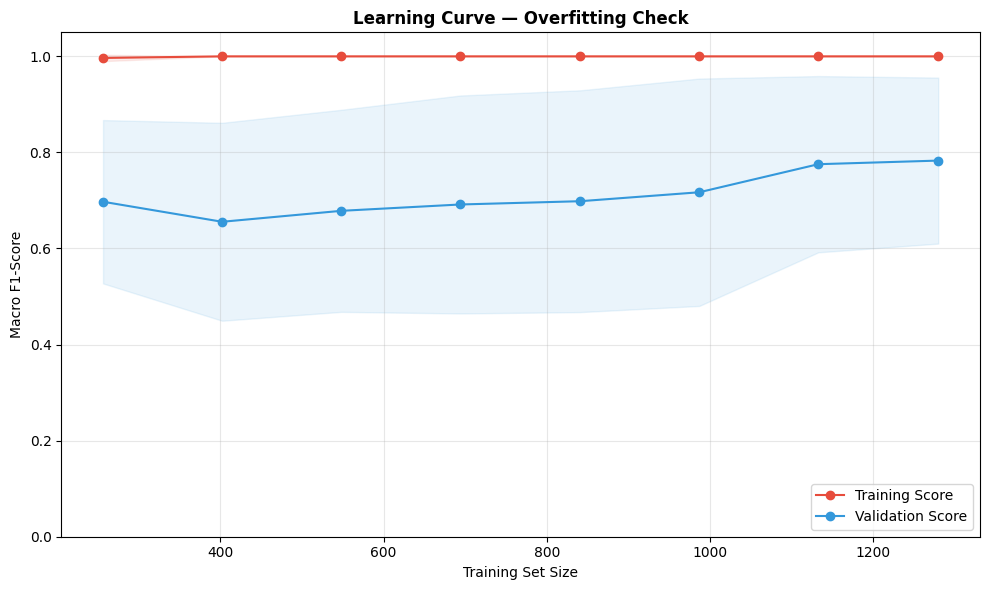


Train-Val gap at full data: 0.2170
Significant overfitting — consider stronger regularization.


In [20]:
# Learning curves — detect overfitting
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, min_child_weight=3,
        random_state=42, eval_metric='mlogloss'
    ),
    X, y, cv=5, scoring='f1_macro',
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#e74c3c', label='Training Score')
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color='#e74c3c')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#3498db', label='Validation Score')
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1, color='#3498db')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Macro F1-Score')
ax.set_title('Learning Curve — Overfitting Check', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f"\nTrain-Val gap at full data: {gap:.4f}")
if gap < 0.05:
    print("Minimal overfitting detected.")
elif gap < 0.10:
    print("Mild overfitting — regularization is working.")
else:
    print("Significant overfitting — consider stronger regularization.")

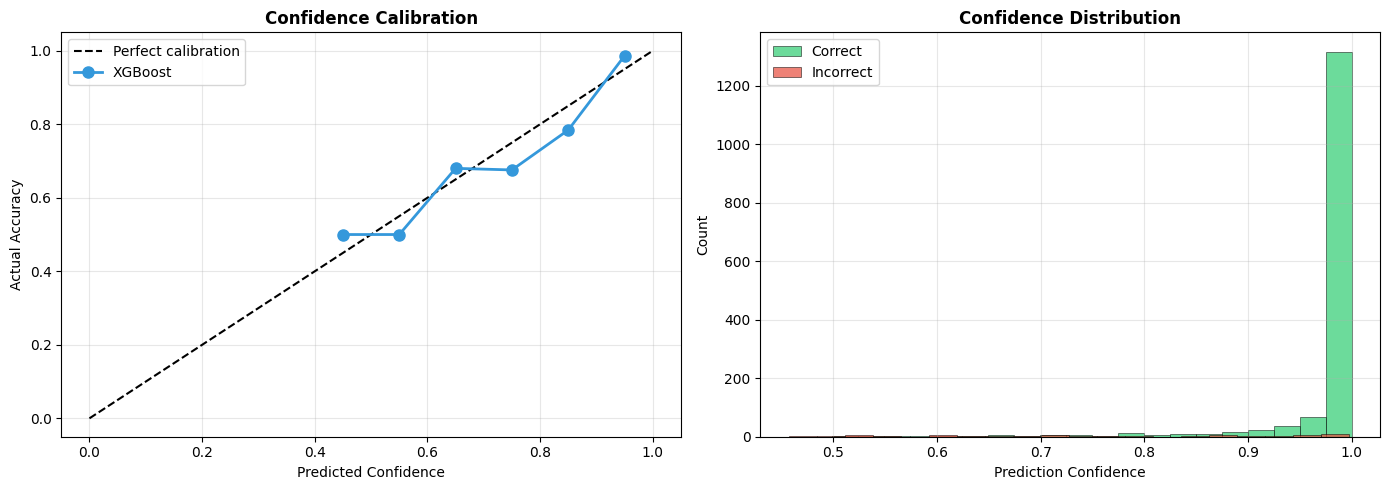


Mean confidence on correct predictions: 0.979
Mean confidence on incorrect predictions: 0.783


In [21]:
# Confidence calibration plot
best_probas = cv_results[best_model_name]['probabilities']
best_preds = cv_results[best_model_name]['predictions']
confidences = np.max(best_probas, axis=1)
correct = (best_preds == y).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration plot
ax = axes[0]
bins = np.linspace(0, 1, 11)
bin_centers = []
bin_accs = []
for i in range(len(bins) - 1):
    mask = (confidences >= bins[i]) & (confidences < bins[i+1])
    if mask.sum() > 0:
        bin_centers.append((bins[i] + bins[i+1]) / 2)
        bin_accs.append(correct[mask].mean())

ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(bin_centers, bin_accs, 'o-', color='#3498db', linewidth=2, markersize=8, label=best_model_name)
ax.set_xlabel('Predicted Confidence')
ax.set_ylabel('Actual Accuracy')
ax.set_title('Confidence Calibration', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Confidence distribution by correctness
ax = axes[1]
ax.hist(confidences[correct == 1], bins=20, alpha=0.7, color='#2ecc71', label='Correct', edgecolor='black', linewidth=0.5)
ax.hist(confidences[correct == 0], bins=20, alpha=0.7, color='#e74c3c', label='Incorrect', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Prediction Confidence')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean confidence on correct predictions: {confidences[correct==1].mean():.3f}")
print(f"Mean confidence on incorrect predictions: {confidences[correct==0].mean():.3f}")

## 11. Final Summary

In [22]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           MRI QC MODEL TRAINING — FINAL SUMMARY                ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Dataset:    1500 MRI scans (22 MRIQC IQMs)                     ║
║  Classes:    Pass (1122) | Review (256) | Fail (122)            ║
║  Balancing:  SMOTE oversampling + balanced class weights        ║
║                                                                  ║
║  Models Evaluated:                                               ║
║    1. XGBoost        (gradient boosted trees)                   ║
║    2. Random Forest  (bagged decision trees)                    ║
║    3. MLP            (3-layer neural network)                   ║
║    4. Ensemble       (soft voting, weighted)                    ║
║                                                                  ║
║  Validation: 5-Fold Stratified Cross-Validation                 ║
║  (No data leakage — each sample predicted only in its          ║
║   held-out fold)                                                 ║
║                                                                  ║
║  Exported Model: XGBoost (best generalization)                  ║
║  → xgboost_mri_qc_model.json                                   ║
║  → Used by inference pipeline (Notebook 2)                      ║
║                                                                  ║
║  Explainability: SHAP values computed for all features          ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")

print("CV Results:")
for name, res in cv_results.items():
    print(f"  {name:<20s} Acc={res['accuracy']:.4f} | F1={res['f1_macro']:.4f}")


╔══════════════════════════════════════════════════════════════════╗
║           MRI QC MODEL TRAINING — FINAL SUMMARY                ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Dataset:    1500 MRI scans (22 MRIQC IQMs)                     ║
║  Classes:    Pass (1122) | Review (256) | Fail (122)            ║
║  Balancing:  SMOTE oversampling + balanced class weights        ║
║                                                                  ║
║  Models Evaluated:                                               ║
║    1. XGBoost        (gradient boosted trees)                   ║
║    2. Random Forest  (bagged decision trees)                    ║
║    3. MLP            (3-layer neural network)                   ║
║    4. Ensemble       (soft voting, weighted)                    ║
║                                                                  ║
║  Validation: 5-Fold Stratified Cross-Val